In [2]:
import math

import matplotlib.pyplot as plt
import os

import keras
from keras import *
from keras.layers import *
from keras.activations import *
from keras.models import load_model, save_model
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt

In [71]:
model_name = 'regression_simple_trained_model.h5'
nsamples = 1000
val_ratio = 0.3
test_ratio = 0.2
x_values = np.random.uniform(low=0, high=(2 * math.pi), size=nsamples)
y_values = np.sin(x_values)

In [72]:
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

In [79]:
print(x_val.shape, x_test.shape, x_train.shape)
print(y_val.shape, y_test.shape, y_train.shape)

(300,) (200,) (500,)
(300,) (200,) (500,)


<function matplotlib.pyplot.show(close=None, block=None)>

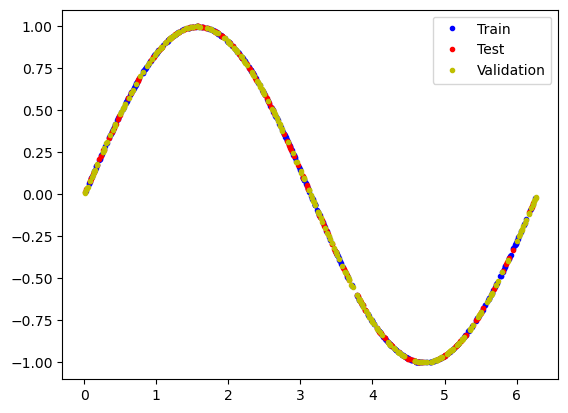

In [80]:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validation")
plt.legend()
plt.show

In [81]:
model = keras.Sequential()
model.add(layers.Dense(18, activation='relu', name='layer1', input_shape=(1,)))
model.add(layers.Dense(18, activation='relu', name='layer2'))
#model.add(layers.Dense(10, activation='relu', name='layer3'))
#model.add(layers.Dense(10, activation='relu', name='layer4'))
model.add(layers.Dense(1))

model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer1 (Dense)               (None, 18)                36        
_________________________________________________________________
layer2 (Dense)               (None, 18)                342       
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 19        
Total params: 397
Trainable params: 397
Non-trainable params: 0
_________________________________________________________________


Epoch 1/500
5/5 [==============================] - 0s 29ms/step - loss: 0.9458 - mae: 0.9458 - val_loss: 0.9027 - val_mae: 0.9027
Epoch 2/500
5/5 [==============================] - 0s 11ms/step - loss: 0.8520 - mae: 0.8520 - val_loss: 0.8264 - val_mae: 0.8264
Epoch 3/500
5/5 [==============================] - 0s 12ms/step - loss: 0.7899 - mae: 0.7899 - val_loss: 0.7644 - val_mae: 0.7644
Epoch 4/500
5/5 [==============================] - 0s 10ms/step - loss: 0.7395 - mae: 0.7395 - val_loss: 0.7083 - val_mae: 0.7083
Epoch 5/500
5/5 [==============================] - 0s 12ms/step - loss: 0.6939 - mae: 0.6939 - val_loss: 0.6572 - val_mae: 0.6572
Epoch 6/500
5/5 [==============================] - 0s 10ms/step - loss: 0.6506 - mae: 0.6506 - val_loss: 0.6068 - val_mae: 0.6068
Epoch 7/500
5/5 [==============================] - 0s 13ms/step - loss: 0.6077 - mae: 0.6077 - val_loss: 0.5726 - val_mae: 0.5726
Epoch 8/500
5/5 [==============================] - 0s 13ms/step - loss: 0.5793 - mae: 0.57

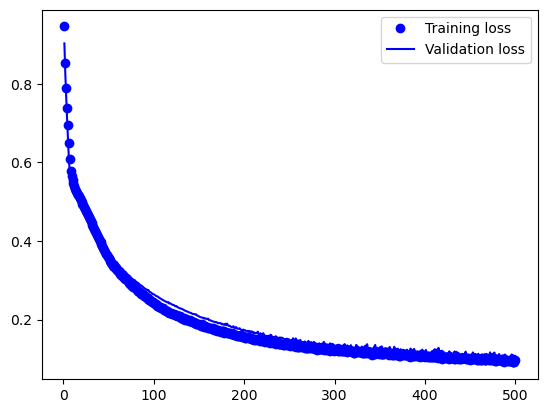

In [82]:
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.show()

In [83]:
print(x_test.shape)

(200,)


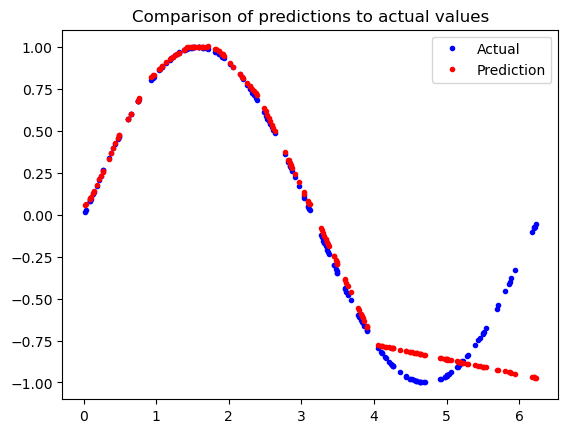

In [84]:
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparison of predictions to actual values")
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Prediction')
plt.legend()
plt.show()

In [85]:
# test data to c file 
save_model(model, model_name)

In [86]:
from nnom import *


model = load_model(model_name)
evaluate_model(model=model, x_test=x_test, y_test=y_test)

7/7 - 0s - loss: 0.0817 - mae: 0.0817
Test loss: 0.08169826865196228
Top 1: 0.08169826865196228


[0.08169826865196228, 0.08169826865196228]

In [88]:
# generate_model(model, np.vstack((x_train, x_test)), name='regression_weights.h')

generate_model(model, x_test=x_test)

layer1_input Quantized method: max-min  Values max: 6.229929607291244 min: 0.014778173465060955 dec bit 4
layer1 Quantized method: max-min  Values max: 6.229929607291244 min: 0.014778173465060955 dec bit 4
layer2 Quantized method: max-min  Values max: 6.229929607291244 min: 0.014778173465060955 dec bit 4
dense_4 Quantized method: max-min  Values max: 1.0039685 min: -0.9728569 dec bit 6
quantisation list {'layer1_input': [4, 0], 'layer1': [4, 0], 'layer2': [4, 0], 'dense_4': [6, 0]}
quantizing weights for layer layer1
    tensor_layer1_kernel_0 dec bit 7
    tensor_layer1_bias_0 dec bit 7


d:\Git Repo\nRF5_SDK_15.2.0\My_Projects\EdgeECG\NN-Weights+Biases\nnom\nnom.py:337: SyntaxWarning: "is" with a literal. Did you mean "=="?
  activation = nnom_tanh if cfg['activation'] is 'tanh' else nnom_sigmoid
d:\Git Repo\nRF5_SDK_15.2.0\My_Projects\EdgeECG\NN-Weights+Biases\nnom\nnom.py:337: SyntaxWarning: "is" with a literal. Did you mean "=="?
  activation = nnom_tanh if cfg['activation'] is 'tanh' else nnom_sigmoid
d:\Git Repo\nRF5_SDK_15.2.0\My_Projects\EdgeECG\NN-Weights+Biases\nnom\nnom.py:337: SyntaxWarning: "is" with a literal. Did you mean "=="?
  activation = nnom_tanh if cfg['activation'] is 'tanh' else nnom_sigmoid
d:\Git Repo\nRF5_SDK_15.2.0\My_Projects\EdgeECG\NN-Weights+Biases\nnom\nnom.py:337: SyntaxWarning: "is" with a literal. Did you mean "=="?
  activation = nnom_tanh if cfg['activation'] is 'tanh' else nnom_sigmoid


UnboundLocalError: local variable 'bias_shift' referenced before assignment